# Synthetic Control — Basque Terrorism & GDP per Capita

Reads in the region-year panel and confirms the treated unit, donor pool, and time span
ahead of building the synthetic control (Abadie & Gardeazabal 2003).

| | |
|---|---|
| **Treatment** | Onset of ETA terrorist activity (late 1960s/1970s) |
| **Treated unit** | `Basque Country (Pais Vasco)` |
| **Outcome** | `gdpcap` — GDP per capita |
| **Panel** | 18 Spanish regions (incl. national aggregate `Spain (Espana)`), 1955–1997 |
| **Dataset** | Abadie, Diamond & Hainmueller replication data |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LassoCV

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv(Path("../data/raw/basque.csv"))

# set the parameters
TREATED_REGION = "Basque Country (Pais Vasco)"
EXCLUDE_UNIT = "Spain (Espana)"  # national aggregate, not a donor region
CONTROL_REGIONS = [region for region in df['regionname'].unique() if region not in [TREATED_REGION, EXCLUDE_UNIT]]
EVENT_START = 1976

print(f"Treated unit  : {TREATED_REGION}")
print(f"Donor regions : {len(CONTROL_REGIONS)}")
print(f"Years         : {df['year'].min():.0f}\u2013{df['year'].max():.0f}")
print(f"Shape         : {df.shape}")


Treated unit  : Basque Country (Pais Vasco)
Donor regions : 16
Years         : 1955–1997
Shape         : (774, 17)


In [3]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


regionno                   0
regionname                 0
year                       0
gdpcap                     0
sec.agriculture          684
sec.energy               684
sec.industry             684
sec.construction         684
sec.services.venta       684
sec.services.nonventa    684
school.illit             666
school.prim              666
school.med               666
school.high              666
school.post.high         666
popdens                  756
invest                   198
dtype: int64

## generate the synthetic control

In [4]:
def get_synthetic_control_estimate(df, event_start, treated_region, control_regions):
    # pivot once, over the full period — pre-period is later sliced from this
    # rather than re-filtering df, so pre- and full-period matrices share
    # identical column ordering/labels by construction
    control_pivot = df[df['regionname'].isin(control_regions)].pivot_table(
        index='year', columns='regionname', values='gdpcap', aggfunc='mean'
    )
    treated_actual = df[df['regionname'] == treated_region].set_index('year')['gdpcap']

    # weights are estimated on pre-treatment years only, so they reflect how
    # the treated region tracked donors *before* the intervention
    is_preperiod = control_pivot.index < event_start
    preperiod_control = control_pivot.loc[is_preperiod]
    # sliced from treated_actual (not a separate pivot) to guarantee the same
    # year index as preperiod_control, avoiding silent misalignment on .fit()
    preperiod_treatment = treated_actual.loc[is_preperiod].values

    lasso_model = LassoCV(cv=5, max_iter=10000).fit(preperiod_control, preperiod_treatment)
    # index by the fitted matrix's actual columns, not a separately-built
    # region list — pivot_table sorts columns alphabetically, and a mismatched
    # list here silently mislabels which weight belongs to which region
    lasso_coefficients = pd.Series(lasso_model.coef_, index=preperiod_control.columns)

    # apply pre-period weights across the full timeline to get the
    # counterfactual trajectory for both pre- and post-treatment years
    synthetic_control = control_pivot.dot(lasso_coefficients) + lasso_model.intercept_
    # actual minus synthetic: negative gap = treatment lowered the outcome
    treatment_effect = treated_actual - synthetic_control

    # average post-treatment gap = estimated average treatment effect
    postperiod = treatment_effect[treatment_effect.index > event_start]
    ate = postperiod.mean()

    return ate, treatment_effect, treated_actual, synthetic_control

In [5]:
ate, treatment_effect, treated_actual, synthetic_control = get_synthetic_control_estimate(df, EVENT_START, TREATED_REGION, CONTROL_REGIONS)

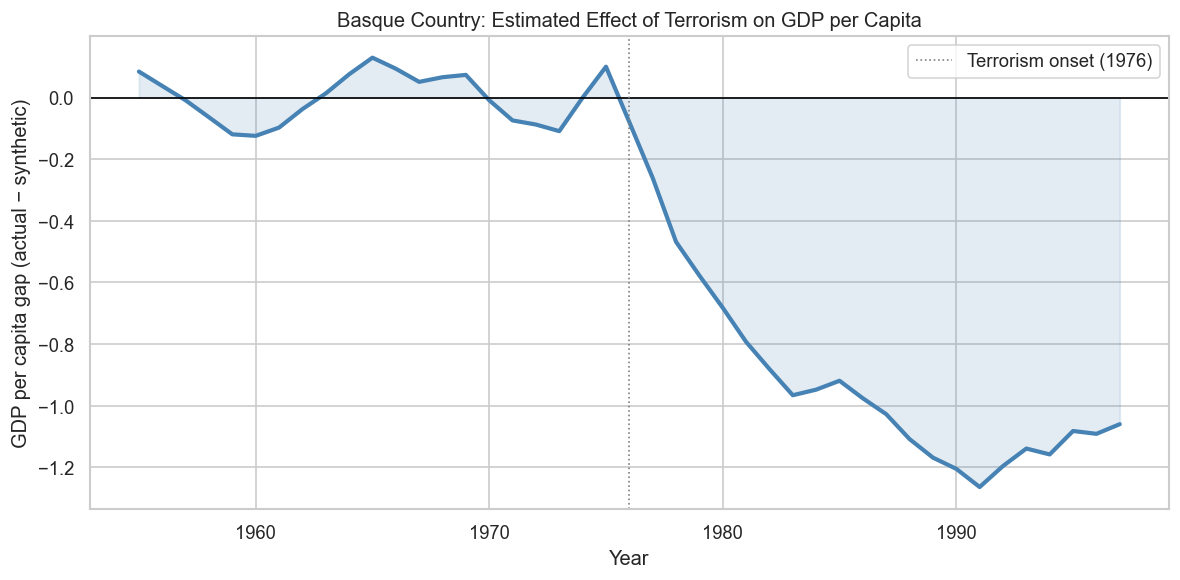

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(treatment_effect.index, treatment_effect.values, color="steelblue", linewidth=2.5)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(EVENT_START, color="grey", linestyle=":", linewidth=1, label=f"Terrorism onset ({EVENT_START})")
ax.fill_between(treatment_effect.index, treatment_effect.values, 0, color="steelblue", alpha=0.15)

ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita gap (actual − synthetic)")
ax.set_title("Basque Country: Estimated Effect of Terrorism on GDP per Capita")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
postperiod = treatment_effect[treatment_effect.index > EVENT_START]
synthetic_postperiod_mean = synthetic_control[synthetic_control.index > EVENT_START].mean()

print("Post-treatment period treatment effect: ")
print(round(postperiod.mean(), 3))
print(round(100 * postperiod.mean() / synthetic_postperiod_mean, 1), '%')

Post-treatment period treatment effect: 
-0.951
-10.7 %


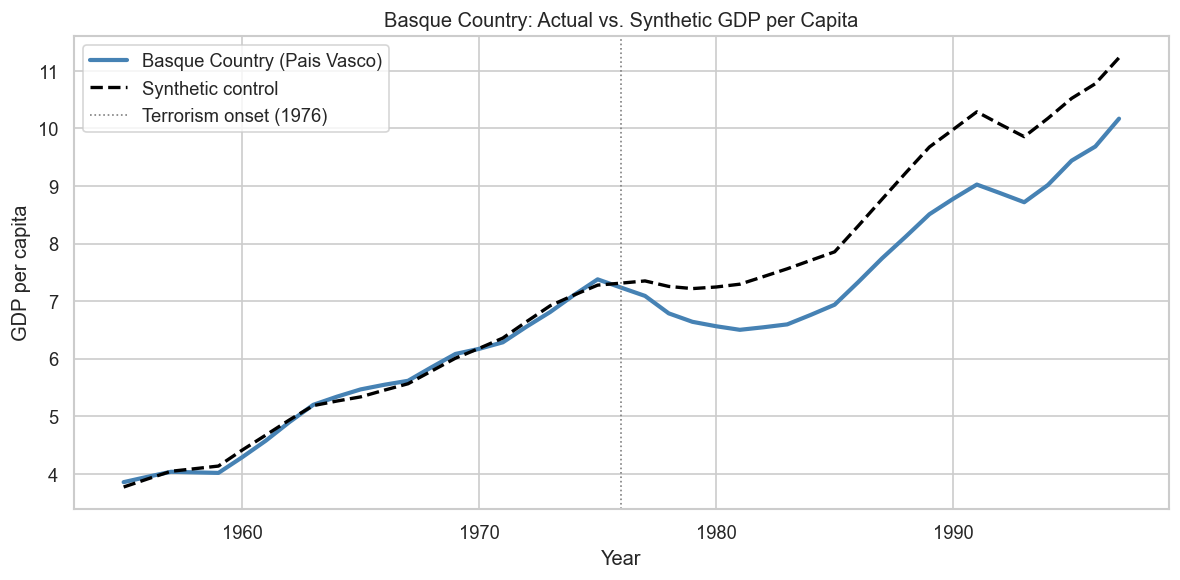

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(treated_actual.index, treated_actual.values, color="steelblue", linewidth=2.5, label=TREATED_REGION)
ax.plot(synthetic_control.index, synthetic_control.values, color="black", linestyle="--", linewidth=2, label="Synthetic control")
ax.axvline(EVENT_START, color="grey", linestyle=":", linewidth=1, label=f"Terrorism onset ({EVENT_START})")

ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita")
ax.set_title("Basque Country: Actual vs. Synthetic GDP per Capita")
ax.legend()
plt.tight_layout()
plt.show()


## permuation test

In [9]:
placebo_ates = []
for placebo_region in CONTROL_REGIONS:
    placebo_control_regions = [region for region in CONTROL_REGIONS if region != placebo_region]
    placebo_ate, _, _, _ = get_synthetic_control_estimate(
        df, EVENT_START, treated_region=placebo_region, control_regions=placebo_control_regions
    )
    placebo_ates.append(placebo_ate)
    print(placebo_region, placebo_ate)

Andalucia -0.22705804044156833
Aragon 0.46887935735827907
Principado De Asturias -0.6872801161367843
Baleares (Islas) -0.1904784027185894
Canarias 0.030203328655529618
Cantabria -0.2630869294509335


Castilla Y Leon 0.22397476368212701
Castilla-La Mancha -0.20157398755496833
Cataluna -0.09944509176586523
Comunidad Valenciana 0.22329820045525675
Extremadura 0.520199186719405


Galicia 0.2207624679204446
Madrid (Comunidad De) -0.40929570547157973
Murcia (Region de) -0.2664150577505386
Navarra (Comunidad Foral De) 0.13489116391847697
Rioja (La) 0.6571351366396924


(array([1., 0., 1., 5., 1., 1., 4., 0., 2., 1.]),
 array([-0.68728012, -0.55283859, -0.41839707, -0.28395554, -0.14951402,
        -0.01507249,  0.11936904,  0.25381056,  0.38825209,  0.52269361,
         0.65713514]),
 <BarContainer object of 10 artists>)

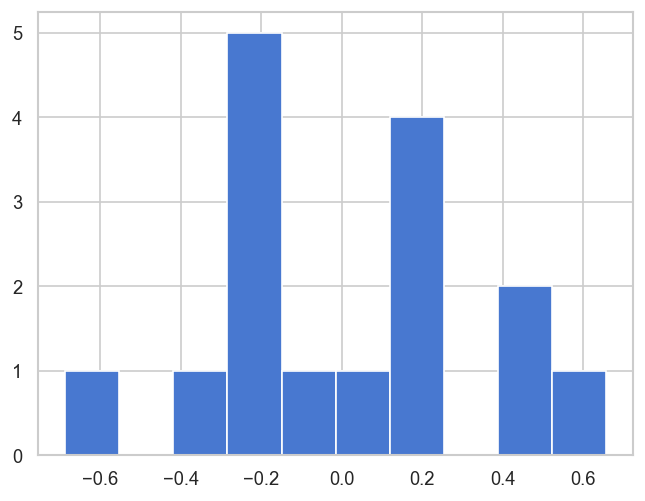

In [10]:
plt.hist(placebo_ates)